In [1]:
!pip install nltk --quiet

# ── Imports ──────────────────────────────────────────────────
import nltk                          # Natural Language Toolkit
import pandas as pd                  # For working with tables/data
import matplotlib.pyplot as plt      # For creating charts
import matplotlib.patches as mpatches
import seaborn as sns                # For beautiful charts
from nltk.sentiment.vader import SentimentIntensityAnalyzer  # Our main tool

# Download VADER's word dictionary (only runs once)
nltk.download('vader_lexicon')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
# Load the CSV file you uploaded
df = pd.read_csv("internship_feedback.csv")

# Preview the first 5 rows
print(f"✅ Dataset loaded! Total rows: {len(df)}")
print("\n── First 5 rows ──")
df.head()

✅ Dataset loaded! Total rows: 120

── First 5 rows ──


,feedback_id,feedback_text,source,intern_department,internship_month
0,1,The mentorship I received was absolutely outst...,Survey,Data Science,January
1,2,I learned more in these 3 months than in my en...,Survey,Software Engineering,February
2,3,My supervisor was always available and gave co...,Survey,Marketing,January
3,4,The projects assigned were real and impactful ...,Survey,Data Science,March
4,5,I felt like a genuine team member and not just...,Survey,Finance,February


In [3]:
# (EDA) Exploratory Data Analysis

print("── Dataset Shape (rows, columns) ──")
print(df.shape)

print("\n── Column Names ──")
print(df.columns.tolist())

print("\n── Data Types ──")
print(df.dtypes)

print("\n── Feedback Sources ──")
print(df['source'].value_counts())

print("\n── Departments ──")
print(df['intern_department'].value_counts())

print("\n── Any Missing Values? ──")
print(df.isnull().sum())

── Dataset Shape (rows, columns) ──
(120, 5)

── Column Names ──
['feedback_id', 'feedback_text', 'source', 'intern_department', 'internship_month']

── Data Types ──
feedback_id           int64
feedback_text        object
source               object
intern_department    object
internship_month     object
dtype: object

── Feedback Sources ──
source
Comment         50
Survey          40
Social Media    30
Name: count, dtype: int64

── Departments ──
intern_department
Data Science            27
Software Engineering    24
Marketing               24
Finance                 24
HR                      21
Name: count, dtype: int64

── Any Missing Values? ──
feedback_id          0
feedback_text        0
source               0
intern_department    0
internship_month     0
dtype: int64


In [4]:
# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# ── Function to classify sentiment ───────────────────────────
def classify_sentiment(text):
    """
    Takes a piece of text and returns:
    - compound score (a number from -1.0 to +1.0)
    - sentiment label (Positive / Neutral / Negative)
    """
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']

    if compound >= 0.05:
        return compound, "Positive"
    elif compound <= -0.05:
        return compound, "Negative"
    else:
        return compound, "Neutral"

# ── Apply the function to every row ──────────────────────────
df[['compound_score', 'sentiment']] = df['feedback_text'].apply(
    lambda text: pd.Series(classify_sentiment(text))
)

print("✅ Sentiment analysis complete!")
print("\n── Sample Results ──")
df[['feedback_text', 'compound_score', 'sentiment']].head(10)

✅ Sentiment analysis complete!

── Sample Results ──


,feedback_text,compound_score,sentiment
0,The mentorship I received was absolutely outst...,0.6478,Positive
1,I learned more in these 3 months than in my en...,0.0000,Neutral
2,My supervisor was always available and gave co...,0.0000,Neutral
3,The projects assigned were real and impactful ...,0.5709,Positive
4,I felt like a genuine team member and not just...,0.3612,Positive
5,The company culture is warm welcoming and trul...,0.8957,Positive
6,I improved my Python and machine learning skil...,0.4767,Positive
7,The structured onboarding process made me feel...,0.5106,Positive
8,Working on live client projects gave me exposu...,0.0000,Neutral
9,I would 100 percent recommend this internship ...,0.3612,Positive


In [5]:
# Show all columns in a clean format
pd.set_option('display.max_colwidth', 80)

print("═" * 60)
print("       INTERNSHIP FEEDBACK SENTIMENT ANALYSIS RESULTS")
print("═" * 60)

# Show counts
summary = df['sentiment'].value_counts()
print(f"\n📊 SUMMARY")
print(f"   Positive feedbacks : {summary.get('Positive', 0)}")
print(f"   Neutral  feedbacks : {summary.get('Neutral', 0)}")
print(f"   Negative feedbacks : {summary.get('Negative', 0)}")
print(f"   Total              : {len(df)}")

# Show percentage breakdown
print(f"\n📈 PERCENTAGE BREAKDOWN")
for label, count in summary.items():
    pct = (count / len(df)) * 100
    print(f"   {label:10s}: {pct:.1f}%")

════════════════════════════════════════════════════════════
       INTERNSHIP FEEDBACK SENTIMENT ANALYSIS RESULTS
════════════════════════════════════════════════════════════

📊 SUMMARY
   Positive feedbacks : 65
   Neutral  feedbacks : 27
   Negative feedbacks : 28
   Total              : 120

📈 PERCENTAGE BREAKDOWN
   Positive  : 54.2%
   Negative  : 23.3%
   Neutral   : 22.5%


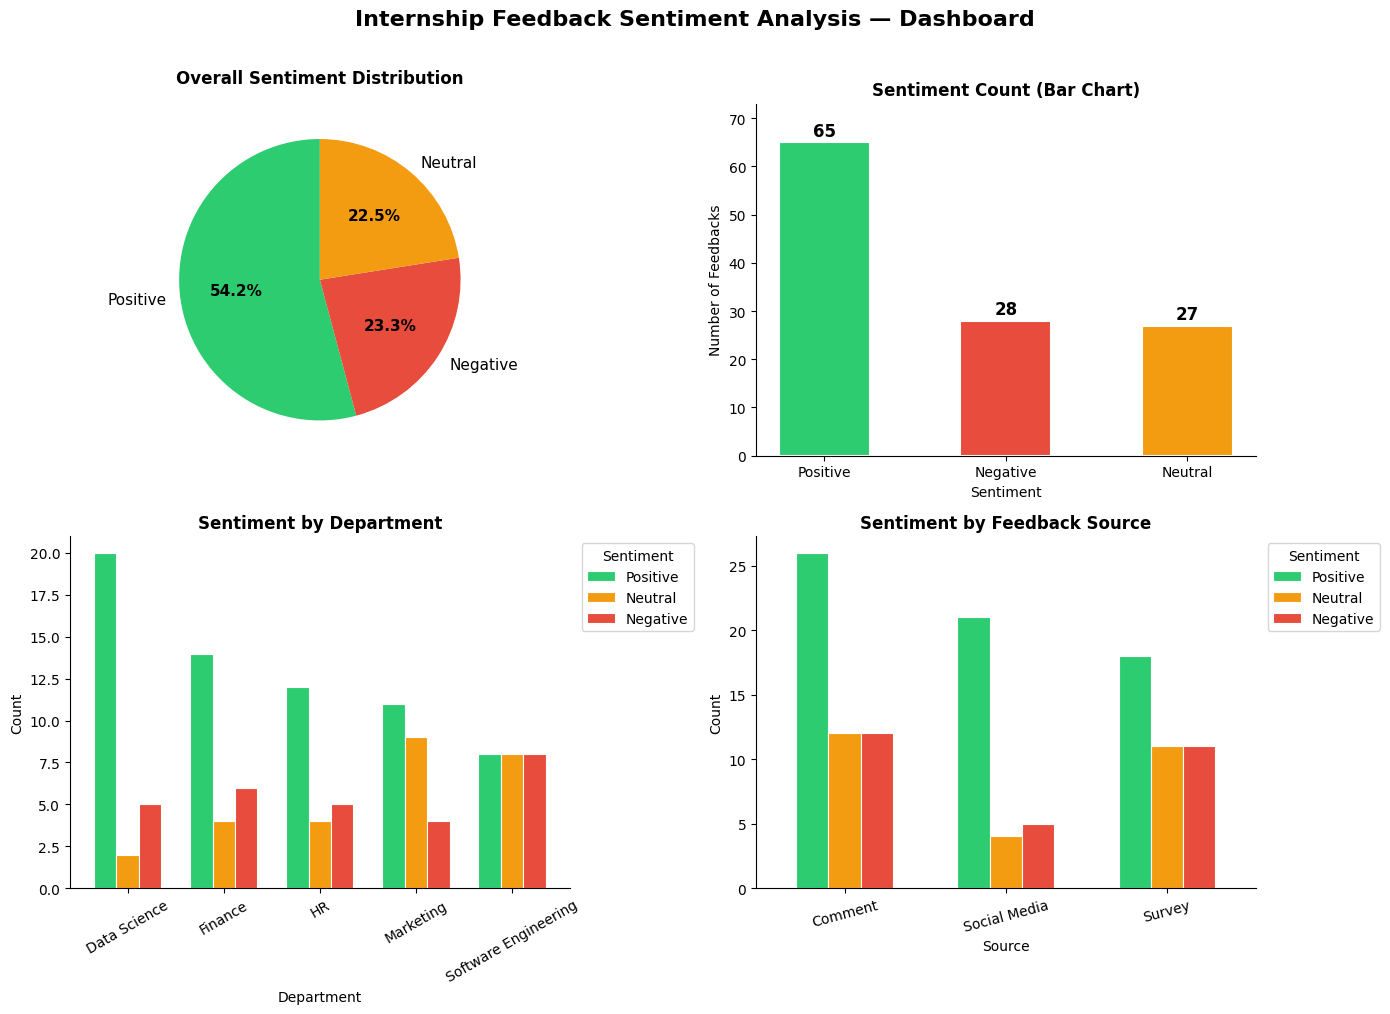

✅ Dashboard saved as 'sentiment_dashboard.png'


In [6]:
# Visualizations
# ── Color palette ─────────────────────────────────────────────
colors = {
    "Positive": "#2ecc71",   # Green
    "Neutral":  "#f39c12",   # Orange
    "Negative": "#e74c3c"    # Red
}

sentiment_counts = df['sentiment'].value_counts()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Internship Feedback Sentiment Analysis — Dashboard",
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Pie Chart ────────────────────────────────────────
ax1 = axes[0, 0]
pie_colors = [colors[s] for s in sentiment_counts.index]
wedges, texts, autotexts = ax1.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title("Overall Sentiment Distribution", fontweight='bold', pad=15)

# ── Chart 2: Bar Chart ────────────────────────────────────────
ax2 = axes[0, 1]
bar_colors = [colors[s] for s in sentiment_counts.index]
bars = ax2.bar(sentiment_counts.index, sentiment_counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sentiment_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_title("Sentiment Count (Bar Chart)", fontweight='bold')
ax2.set_xlabel("Sentiment")
ax2.set_ylabel("Number of Feedbacks")
ax2.set_ylim(0, sentiment_counts.max() + 8)
ax2.spines[['top', 'right']].set_visible(False)

# ── Chart 3: Sentiment by Department ─────────────────────────
ax3 = axes[1, 0]
dept_sentiment = df.groupby(['intern_department', 'sentiment']).size().unstack(fill_value=0)
dept_sentiment = dept_sentiment.reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
dept_colors = [colors[c] for c in dept_sentiment.columns]
dept_sentiment.plot(kind='bar', ax=ax3, color=dept_colors,
                    edgecolor='white', linewidth=0.8, width=0.7)
ax3.set_title("Sentiment by Department", fontweight='bold')
ax3.set_xlabel("Department")
ax3.set_ylabel("Count")
ax3.legend(title="Sentiment", bbox_to_anchor=(1.01, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=30)
ax3.spines[['top', 'right']].set_visible(False)

# ── Chart 4: Sentiment by Source ─────────────────────────────
ax4 = axes[1, 1]
source_sentiment = df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)
source_sentiment = source_sentiment.reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
src_colors = [colors[c] for c in source_sentiment.columns]
source_sentiment.plot(kind='bar', ax=ax4, color=src_colors,
                      edgecolor='white', linewidth=0.8, width=0.6)
ax4.set_title("Sentiment by Feedback Source", fontweight='bold')
ax4.set_xlabel("Source")
ax4.set_ylabel("Count")
ax4.legend(title="Sentiment", bbox_to_anchor=(1.01, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=15)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("sentiment_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'sentiment_dashboard.png'")

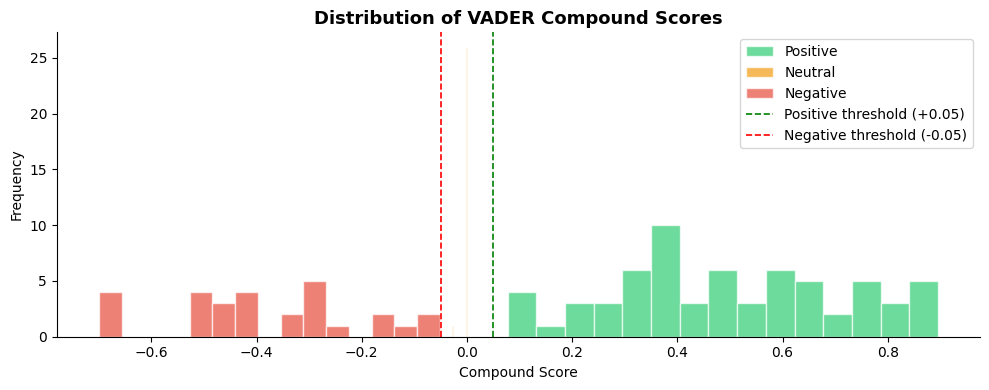

✅ Score distribution chart saved!


In [7]:
# Score Distribution Plot

fig, ax = plt.subplots(figsize=(10, 4))

for sentiment, color in colors.items():
    subset = df[df['sentiment'] == sentiment]['compound_score']
    ax.hist(subset, bins=15, color=color, alpha=0.7, label=sentiment, edgecolor='white')

ax.axvline(x=0.05,  color='green', linestyle='--', linewidth=1.2, label='Positive threshold (+0.05)')
ax.axvline(x=-0.05, color='red',   linestyle='--', linewidth=1.2, label='Negative threshold (-0.05)')
ax.set_title("Distribution of VADER Compound Scores", fontweight='bold', fontsize=13)
ax.set_xlabel("Compound Score")
ax.set_ylabel("Frequency")
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Score distribution chart saved!")

In [8]:
# Save full results
df.to_csv("feedback_results_final.csv", index=False)

# Download it to the computer
from google.colab import files
files.download("feedback_results_final.csv")
files.download("sentiment_dashboard.png")
files.download("score_distribution.png")

print("✅ All files downloaded!")
print("\n── Files ──")
print("   📄 feedback_results_final.csv  → Full data with sentiment labels")
print("   📊 sentiment_dashboard.png     → 4-panel chart dashboard")
print("   📈 score_distribution.png      → Score histogram")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

── Files ──
   📄 feedback_results_final.csv  → Full data with sentiment labels
   📊 sentiment_dashboard.png     → 4-panel chart dashboard
   📈 score_distribution.png      → Score histogram
